# Exp D — rho_B sem Aritmética Inteira: Versão Puramente Contínua

**T. Bandeira · 2026**

O único uso de aritmética inteira no pipeline final (Notas 23–24) é o teste
de divisibilidade `m % b == 0` dentro de `rho_B`. Esta nota investiga se
esse teste pode ser eliminado, substituindo-o pela versão puramente contínua:

```
rho_cont(m, base) = min_{b in base, e>=1} |log(m) - e*log(b)| / log(m)
                    + min sobre pares (b1, b2)
```

**Hipótese:** como a base S_k contém exatamente os fatores primos de qualquer
composto de A_k (pelo Teorema 1), a igualdade log(m) = sum e_i * log(p_i) é
matematicamente exata. O erro de ponto flutuante (float64 ~ 1e-15) deveria
manter rho_cont dos compostos muito abaixo de qualquer limiar prático.

| Exp | Questão |
|-----|---------|
| D1  | Distribuição de rho_cont para primos e compostos em A[k] com base S_k |
| D2  | Gap mínimo: rho_cont(primos) vs rho_cont(compostos) — existe separação? |
| D3  | Recursão C1 com rho_cont puro: taxa de acerto vs versão com divisibilidade |
| D4  | Limiar ótimo rho* para a versão contínua e estabilidade com k crescente |

**Requisitos:** `pip install numpy sympy matplotlib`

In [1]:
from math import log, floor, sqrt
from sympy import isprime, primerange
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

def bloco_A(k):
    return list(range(2**k, 2**(k+1)))

# ── rho_B original (com divisibilidade inteira) ───────────────────────────────
def rho_inteiro(m, base):
    """Versão original: teste de divisibilidade exata primeiro."""
    if m < 2: return 1.0
    for b in base:
        if b >= 2 and m % b == 0:
            return 0.0
    lm  = log(m)
    lbs = [log(b) for b in base if b >= 2]
    if not lbs: return 1.0
    res = lm
    for lb in lbs:
        ef = lm / lb
        for e in range(max(1, int(ef)-1), int(ef)+3):
            res = min(res, abs(lm - e*lb))
    for i in range(len(lbs)):
        for j in range(i, len(lbs)):
            for e1 in range(1, 4):
                rem = lm - e1*lbs[i]
                if rem <= 0: continue
                e2f = rem / lbs[j]
                for e2 in range(max(1, int(e2f)-1), int(e2f)+3):
                    res = min(res, abs(lm - e1*lbs[i] - e2*lbs[j]))
    return res / lm

# ── rho_cont: versão puramente contínua, sem m % b ────────────────────────────
def rho_cont(m, base, e_max=8):
    """
    Versão puramente analítica: sem divisibilidade inteira.
    Busca o mínimo de |log(m) - combinação de logs da base|.
    e_max: expoente máximo testado (padrão 8, cobre potências até 2^8=256).
    """
    if m < 2: return 1.0
    lm  = log(m)
    lbs = [log(b) for b in base if b >= 2]
    if not lbs: return 1.0
    res = lm
    # Singles: e * log(b)
    for lb in lbs:
        for e in range(1, e_max + 1):
            res = min(res, abs(lm - e * lb))
    # Pares: e1*log(b1) + e2*log(b2)
    for i in range(len(lbs)):
        for j in range(i, len(lbs)):
            for e1 in range(1, 5):
                rem = lm - e1 * lbs[i]
                if rem <= 0: continue
                for e2 in range(1, 5):
                    res = min(res, abs(lm - e1*lbs[i] - e2*lbs[j]))
    # Triplos: e1*log(b1) + e2*log(b2) + e3*log(b3) — para compostos com 3 fatores
    for i in range(len(lbs)):
        for j in range(i, len(lbs)):
            for l in range(j, len(lbs)):
                for e1 in range(1, 3):
                    for e2 in range(1, 3):
                        rem = lm - e1*lbs[i] - e2*lbs[j]
                        if rem <= 0: continue
                        for e3 in range(1, 3):
                            res = min(res, abs(lm - e1*lbs[i] - e2*lbs[j] - e3*lbs[l]))
    return res / lm

print('Funções OK ✓')
print()
# Verificação rápida
base_teste = [2, 3, 5, 7]
casos = [(15, False), (17, True), (4, False), (35, False), (19, True)]
print(f'{"m":>5} {"primo":>6} {"rho_int":>12} {"rho_cont":>12} {"acordo":>8}')
for m, eh_primo in casos:
    ri = rho_inteiro(m, base_teste)
    rc = rho_cont(m, base_teste)
    acordo = (ri > 1e-6) == (rc > 1e-6)
    print(f'{m:>5} {str(eh_primo):>6} {ri:>12.2e} {rc:>12.2e} {str(acordo):>8}')

Funções OK ✓

    m  primo      rho_int     rho_cont   acordo
   15  False     0.00e+00     0.00e+00     True
   17   True     2.02e-02     2.02e-02     True
    4  False     0.00e+00     0.00e+00     True
   35  False     0.00e+00     0.00e+00     True
   19   True     1.74e-02     1.74e-02     True


---
## Exp D1 — Distribuição de rho_cont para primos e compostos em A[k]

Para cada bloco A[k] com base S_k (primos dos blocos anteriores),
mede rho_cont de todos os elementos e separa por tipo.

O que esperar:
- Compostos: rho_cont ≈ 0 (erro de ponto flutuante ~ 1e-14)
- Primos: rho_cont > 0 (irredutível — log(p) não é combinação inteira dos logs da base)

Se os dois grupos não se sobrepõem, existe um limiar que separa sem divisibilidade.

In [2]:
# Exp D1: distribuição de rho_cont por bloco

print('Exp D1 — rho_cont para primos e compostos em A[k]')
print('=' * 65)

resultados_d1 = {}

# Construção incremental de S_k (primos acumulados)
S = [2, 3]  # S_1 = A[1]

for k in range(2, 9):
    Ak    = bloco_A(k)
    base  = list(S)  # semente = primos dos blocos anteriores

    dados = []
    for m in Ak:
        ri = rho_inteiro(m, base)
        rc = rho_cont(m, base)
        primo = isprime(m)
        dados.append({'m': m, 'primo': primo, 'rho_int': ri, 'rho_cont': rc})

    primos_d    = [d for d in dados if d['primo']]
    compostos_d = [d for d in dados if not d['primo']]

    rc_primos    = [d['rho_cont'] for d in primos_d]
    rc_compostos = [d['rho_cont'] for d in compostos_d]

    rho_min_primos    = min(rc_primos)    if rc_primos    else float('nan')
    rho_max_compostos = max(rc_compostos) if rc_compostos else 0.0
    gap               = rho_min_primos - rho_max_compostos
    separavel         = gap > 0

    # Compostos que escapam (rho_cont > 1e-6)
    escapam = [d for d in compostos_d if d['rho_cont'] > 1e-6]

    resultados_d1[k] = {
        'dados': dados, 'gap': gap, 'separavel': separavel,
        'rho_min_primos': rho_min_primos,
        'rho_max_compostos': rho_max_compostos,
        'escapam': escapam
    }

    print(f'k={k}  A[k]=[{Ak[0]},{Ak[-1]}]  |base|={len(base)}')
    print(f'  rho_cont primos:    min={rho_min_primos:.4e}  '
          f'max={max(rc_primos):.4e}')
    print(f'  rho_cont compostos: min={min(rc_compostos):.4e}  '
          f'max={rho_max_compostos:.4e}')
    print(f'  gap={gap:.4e}  separável={separavel}  '
          f'compostos_escapam={len(escapam)}')
    if escapam:
        for d in escapam[:5]:
            # Fatorar
            fat = []
            temp = d['m']
            for f in range(2, int(sqrt(temp))+1):
                while temp % f == 0:
                    fat.append(f); temp //= f
            if temp > 1: fat.append(temp)
            print(f'    m={d["m"]} fatores={fat} rho_cont={d["rho_cont"]:.4e}')
    print()

    # Atualizar semente com primos do bloco atual
    S = S + [d['m'] for d in primos_d]

Exp D1 — rho_cont para primos e compostos em A[k]
k=2  A[k]=[4,7]  |base|=2
  rho_cont primos:    min=6.8622e-02  max=1.1328e-01
  rho_cont compostos: min=0.0000e+00  max=1.2393e-16
  gap=6.8622e-02  separável=True  compostos_escapam=0

k=3  A[k]=[8,15]  |base|=4
  rho_cont primos:    min=2.8893e-02  max=3.6287e-02
  rho_cont compostos: min=0.0000e+00  max=9.6433e-17
  gap=2.8893e-02  separável=True  compostos_escapam=0

k=4  A[k]=[16,31]  |base|=6
  rho_cont primos:    min=9.2454e-03  max=2.0174e-02
  rho_cont compostos: min=0.0000e+00  max=1.5364e-16
  gap=9.2454e-03  separável=True  compostos_escapam=0

k=5  A[k]=[32,63]  |base|=11
  rho_cont primos:    min=3.9555e-03  max=7.3854e-03
  rho_cont compostos: min=0.0000e+00  max=1.2393e-16
  gap=3.9555e-03  separável=True  compostos_escapam=0

k=6  A[k]=[64,127]  |base|=18
  rho_cont primos:    min=1.6191e-03  max=3.5235e-03
  rho_cont compostos: min=0.0000e+00  max=2.2942e-03
  gap=-6.7506e-04  separável=False  compostos_escapam=2
    

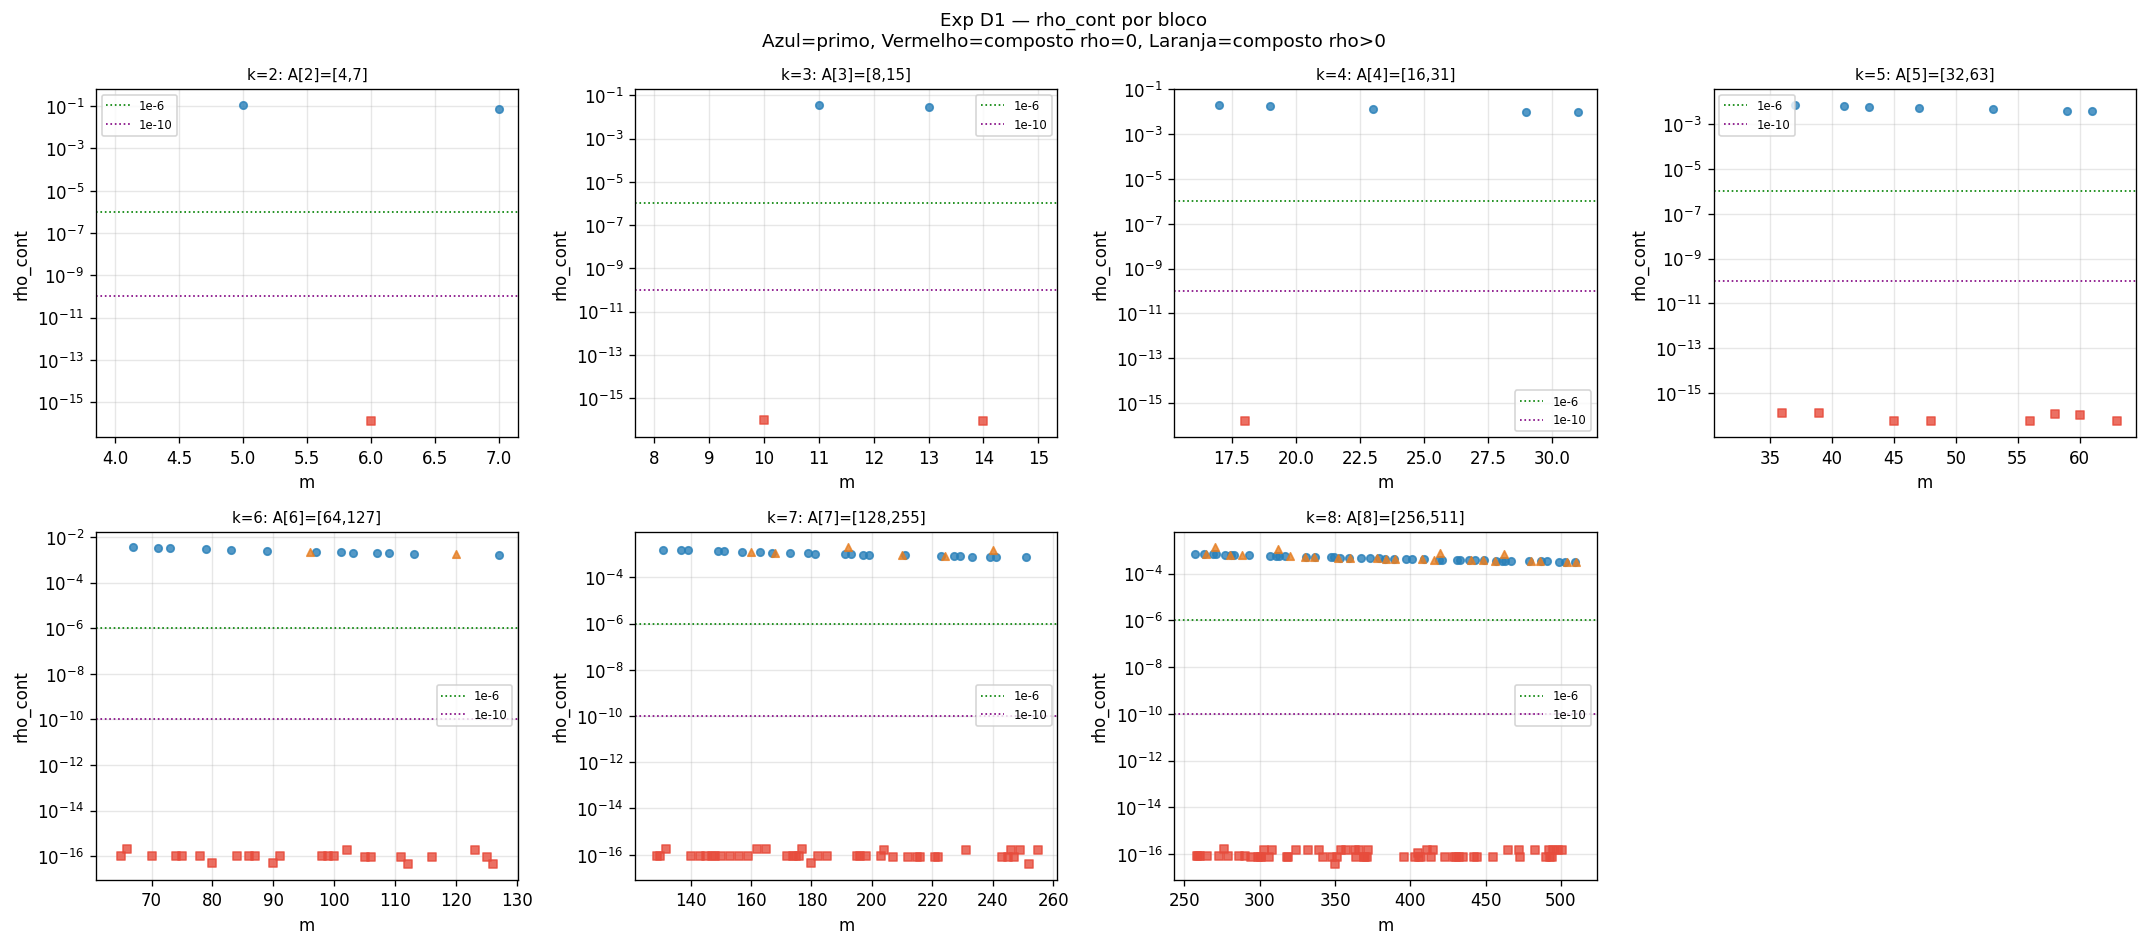

In [3]:
# Exp D1b — visualização: scatter rho_cont por bloco

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Exp D1 — rho_cont por bloco\nAzul=primo, Vermelho=composto rho=0, Laranja=composto rho>0',
             fontsize=11)

for ax, k in zip(axes.flat, range(2, 10)):
    if k not in resultados_d1:
        ax.axis('off')
        continue
    res  = resultados_d1[k]
    Ak   = bloco_A(k)

    for d in res['dados']:
        if d['primo']:
            cor, marker, z = '#2980b9', 'o', 4
        elif d['rho_cont'] <= 1e-14:
            cor, marker, z = '#e74c3c', 's', 2
        else:
            cor, marker, z = '#e67e22', '^', 5
        ax.scatter(d['m'], d['rho_cont'], color=cor, marker=marker,
                   s=20, zorder=z, alpha=0.8)

    ax.axhline(1e-6,  color='green',  lw=1, ls=':', label='1e-6')
    ax.axhline(1e-10, color='purple', lw=1, ls=':', label='1e-10')
    ax.set_yscale('log')
    ax.set_title(f'k={k}: A[{k}]=[{Ak[0]},{Ak[-1]}]', fontsize=9)
    ax.set_xlabel('m')
    ax.set_ylabel('rho_cont')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('expD1_rho_cont.png', bbox_inches='tight')
plt.show()

---
## Exp D2 — Gap mínimo e limiar ótimo por bloco

Se os grupos são separáveis, qual o limiar rho* ótimo?
Ele cresce, decresce ou estabiliza com k?

Um limiar estável com k seria evidência de que a separação é estrutural
e não depende do tamanho do bloco.

In [4]:
# Exp D2: gap e limiar ótimo por bloco

print('Exp D2 — Gap e limiar ótimo rho_cont por bloco')
print('=' * 65)
print(f'{"k":>4} {"rho_min_primos":>16} {"rho_max_comp":>14} {"gap":>14} '
      f'{"limiar_otimo":>14} {"separavel":>10}')
print('-' * 75)

for k in range(2, 9):
    res = resultados_d1[k]
    rmp = res['rho_min_primos']
    rmc = res['rho_max_compostos']
    gap = res['gap']
    # Limiar ótimo: média geométrica dos dois extremos
    if rmc > 0 and rmp > 0:
        limiar = (rmc * rmp) ** 0.5
    elif rmc == 0:
        limiar = rmp / 2
    else:
        limiar = float('nan')
    sep = '✓' if gap > 0 else '✗'
    print(f'{k:>4} {rmp:>16.4e} {rmc:>14.4e} {gap:>14.4e} {limiar:>14.4e} {sep:>10}')

print()
print('Nota: limiar_otimo = sqrt(rho_max_compostos * rho_min_primos)')
print('      (média geométrica — ponto médio no espaço log)')

Exp D2 — Gap e limiar ótimo rho_cont por bloco
   k   rho_min_primos   rho_max_comp            gap   limiar_otimo  separavel
---------------------------------------------------------------------------
   2       6.8622e-02     1.2393e-16     6.8622e-02     2.9162e-09          ✓
   3       2.8893e-02     9.6433e-17     2.8893e-02     1.6692e-09          ✓
   4       9.2454e-03     1.5364e-16     9.2454e-03     1.1919e-09          ✓
   5       3.9555e-03     1.2393e-16     3.9555e-03     7.0013e-10          ✓
   6       1.6191e-03     2.2942e-03    -6.7506e-04     1.9273e-03          ✗
   7       7.1961e-04     1.9711e-03    -1.2514e-03     1.1910e-03          ✗
   8       3.1554e-04     1.3182e-03    -1.0027e-03     6.4495e-04          ✗

Nota: limiar_otimo = sqrt(rho_max_compostos * rho_min_primos)
      (média geométrica — ponto médio no espaço log)


---
## Exp D3 — Recursão C1 com rho_cont puro

Rodar a recursão completa (como no Exp C1) substituindo rho_inteiro por
rho_cont, com limiar rho* = 1e-6 e também com limiar adaptativo.

Questão: a taxa de acerto se mantém em 100%? Ou compostos escapam?

In [5]:
# Exp D3: recursão com rho_cont puro

def recursao_cont(n_alvo, rho_star=1e-6, verbose=False):
    """
    Recursão C1 usando rho_cont (sem aritmética inteira).
    """
    acumulados = [2, 3]

    for k in range(2, n_alvo + 1):
        candidatos = bloco_A(k)
        semente    = list(acumulados)
        aceitos    = []
        for m in candidatos:
            r = rho_cont(m, semente)
            if r > rho_star:
                aceitos.append(m)
                semente.append(m)
        acumulados = acumulados + aceitos
        if verbose:
            reais = [x for x in candidatos if isprime(x)]
            fps   = [x for x in aceitos if not isprime(x)]
            fns   = [x for x in reais if x not in aceitos]
            print(f'  k={k}: aceitos={aceitos} reais={reais} FP={fps} FN={fns}')

    return acumulados

print('Exp D3 — Recursão com rho_cont (rho* = 1e-6)')
print('=' * 65)

for n_alvo in [5, 6, 7, 8]:
    reais    = list(primerange(2, 2**n_alvo))
    resultado = recursao_cont(n_alvo, rho_star=1e-6)
    ext      = sorted(set(resultado))
    rs       = set(reais)
    es       = set(ext)
    tp       = sorted(es & rs)
    fp       = sorted(es - rs)
    fn       = sorted(rs - es)
    taxa     = 100 * len(tp) / len(rs)
    print(f'n={n_alvo}: {len(tp)}/{len(rs)} ({taxa:.0f}%)  FP={fp}  FN={fn}')

print()
print('Exp D3b — Recursão com rho_cont (rho* = 1e-10)')
print('=' * 65)

for n_alvo in [5, 6, 7, 8]:
    reais    = list(primerange(2, 2**n_alvo))
    resultado = recursao_cont(n_alvo, rho_star=1e-10)
    ext      = sorted(set(resultado))
    rs       = set(reais)
    es       = set(ext)
    tp       = sorted(es & rs)
    fp       = sorted(es - rs)
    fn       = sorted(rs - es)
    taxa     = 100 * len(tp) / len(rs)
    print(f'n={n_alvo}: {len(tp)}/{len(rs)} ({taxa:.0f}%)  FP={fp}  FN={fn}')

Exp D3 — Recursão com rho_cont (rho* = 1e-6)
n=5: 11/11 (100%)  FP=[37, 41, 43, 47, 53, 59, 61]  FN=[]
n=6: 18/18 (100%)  FP=[67, 71, 73, 79, 83, 89, 96, 97, 101, 103, 107, 109, 113, 120, 127]  FN=[]
n=7: 31/31 (100%)  FP=[96, 120, 131, 137, 139, 149, 151, 157, 160, 163, 167, 168, 173, 179, 181, 191, 193, 197, 199, 210, 211, 223, 224, 227, 229, 233, 239, 241, 251]  FN=[]
n=8: 54/54 (100%)  FP=[96, 120, 160, 168, 210, 224, 257, 263, 264, 269, 270, 271, 277, 280, 281, 283, 293, 307, 311, 312, 313, 317, 330, 331, 337, 347, 349, 352, 353, 359, 367, 373, 378, 379, 383, 389, 390, 397, 401, 408, 409, 416, 419, 421, 431, 433, 439, 440, 443, 449, 456, 457, 461, 462, 463, 467, 479, 486, 487, 491, 499, 503, 509, 510]  FN=[]

Exp D3b — Recursão com rho_cont (rho* = 1e-10)
n=5: 11/11 (100%)  FP=[37, 41, 43, 47, 53, 59, 61]  FN=[]
n=6: 18/18 (100%)  FP=[67, 71, 73, 79, 83, 89, 96, 97, 101, 103, 107, 109, 113, 120, 127]  FN=[]
n=7: 31/31 (100%)  FP=[96, 120, 131, 137, 139, 149, 151, 157, 160, 163, 16

In [6]:
# Exp D3c: comparação direta rho_inteiro vs rho_cont por elemento
# Para cada m que diverge entre os dois métodos, mostrar o diagnóstico

print('Exp D3c — Divergências entre rho_inteiro e rho_cont')
print('=' * 65)

S = [2, 3]
divergencias = []

for k in range(2, 9):
    Ak   = bloco_A(k)
    base = list(S)
    for m in Ak:
        ri = rho_inteiro(m, base)
        rc = rho_cont(m, base)
        # Divergência: classificações diferentes com limiar 1e-6
        class_int  = ri > 1e-6
        class_cont = rc > 1e-6
        if class_int != class_cont:
            fat = []
            temp = m
            for f in range(2, int(sqrt(temp))+1):
                while temp % f == 0:
                    fat.append(f); temp //= f
            if temp > 1: fat.append(temp)
            divergencias.append({
                'k': k, 'm': m, 'primo': isprime(m),
                'ri': ri, 'rc': rc,
                'class_int': class_int, 'class_cont': class_cont,
                'fatores': fat
            })
    S = S + [m for m in Ak if isprime(m)]

if divergencias:
    print(f'Total de divergências: {len(divergencias)}')
    print(f'{"k":>3} {"m":>5} {"primo":>6} {"rho_int":>12} {"rho_cont":>12} '
          f'{"class_int":>10} {"class_cont":>11} {"fatores"}')
    for d in divergencias:
        print(f'{d["k"]:>3} {d["m"]:>5} {str(d["primo"]):>6} '
              f'{d["ri"]:>12.4e} {d["rc"]:>12.4e} '
              f'{str(d["class_int"]):>10} {str(d["class_cont"]):>11} '
              f'{d["fatores"]}')
else:
    print('Nenhuma divergência encontrada — rho_cont e rho_inteiro concordam em todos os casos ✓')

Exp D3c — Divergências entre rho_inteiro e rho_cont
Total de divergências: 32
  k     m  primo      rho_int     rho_cont  class_int  class_cont fatores
  6    96  False   0.0000e+00   2.2942e-03      False        True [2, 2, 2, 2, 2, 3]
  6   120  False   0.0000e+00   1.7334e-03      False        True [2, 2, 2, 3, 5]
  7   160  False   0.0000e+00   1.2277e-03      False        True [2, 2, 2, 2, 2, 5]
  7   168  False   0.0000e+00   1.1582e-03      False        True [2, 2, 2, 3, 7]
  7   192  False   0.0000e+00   1.9711e-03      False        True [2, 2, 2, 2, 2, 2, 3]
  7   210  False   0.0000e+00   8.9268e-04      False        True [2, 3, 5, 7]
  7   224  False   0.0000e+00   8.2310e-04      False        True [2, 2, 2, 2, 2, 7]
  7   240  False   0.0000e+00   1.5142e-03      False        True [2, 2, 2, 2, 3, 5]
  8   264  False   0.0000e+00   6.7804e-04      False        True [2, 2, 2, 3, 11]
  8   270  False   0.0000e+00   1.3182e-03      False        True [2, 3, 3, 3, 5]
  8   280  F

---
## Exp D4 — Estabilidade do gap com k crescente

O gap entre rho_min(primos) e rho_max(compostos) decresce com k?
Se sim, existe um k crítico além do qual a separação falha com float64?

Isso determina se a versão contínua é universalmente válida ou apenas
para blocos pequenos.

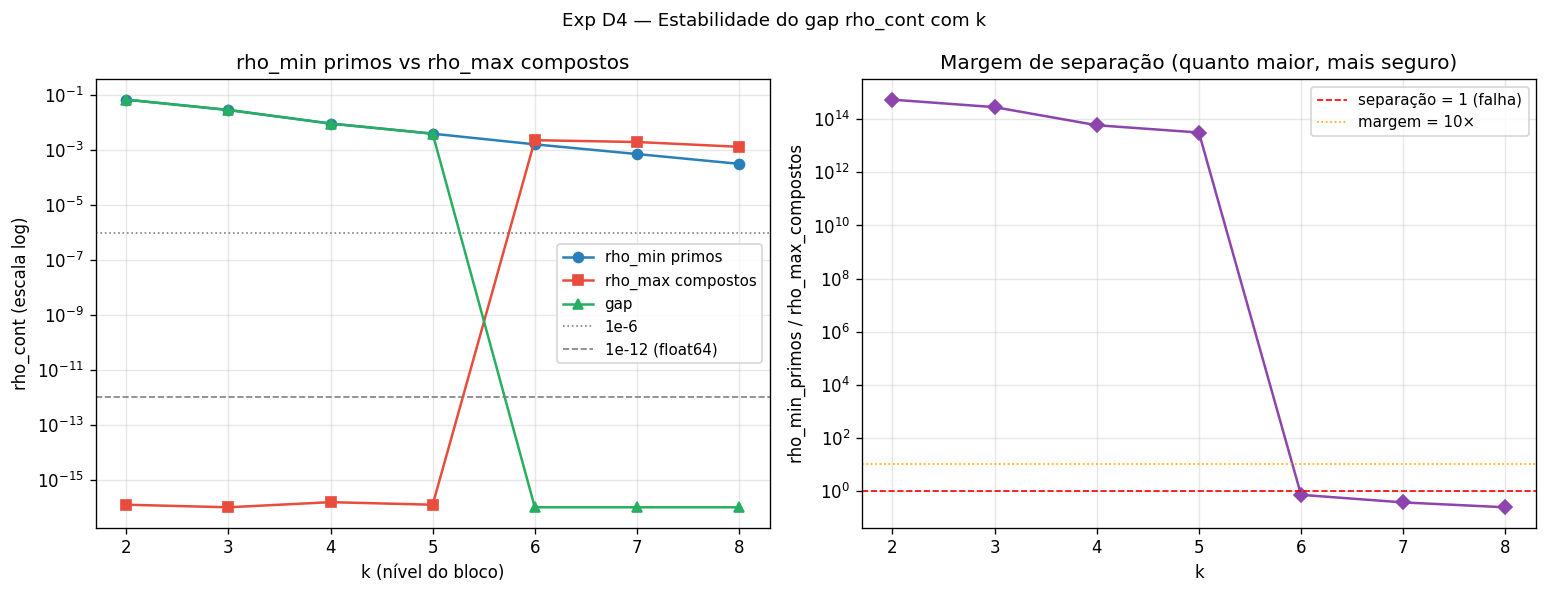

Resumo numérico:
   k   rho_min_primos   rho_max_comp     margem
   2       6.8622e-02     1.2393e-16   5.54e+14
   3       2.8893e-02     9.6433e-17   2.89e+14
   4       9.2454e-03     1.5364e-16   6.02e+13
   5       3.9555e-03     1.2393e-16   3.19e+13
   6       1.6191e-03     2.2942e-03   7.06e-01
   7       7.1961e-04     1.9711e-03   3.65e-01
   8       3.1554e-04     1.3182e-03   2.39e-01


In [7]:
# Exp D4: gap como função de k

ks   = list(range(2, 9))
gaps = [resultados_d1[k]['gap'] for k in ks]
rmps = [resultados_d1[k]['rho_min_primos'] for k in ks]
rmcs = [resultados_d1[k]['rho_max_compostos'] for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Exp D4 — Estabilidade do gap rho_cont com k', fontsize=11)

ax = axes[0]
ax.semilogy(ks, rmps, 'o-', color='#2980b9', label='rho_min primos')
ax.semilogy(ks, [max(r, 1e-16) for r in rmcs], 's-',
            color='#e74c3c', label='rho_max compostos')
ax.semilogy(ks, [max(g, 1e-16) for g in gaps], '^-',
            color='#27ae60', label='gap')
ax.axhline(1e-6,  color='gray', ls=':', lw=1, label='1e-6')
ax.axhline(1e-12, color='gray', ls='--', lw=1, label='1e-12 (float64)')
ax.set_xlabel('k (nível do bloco)')
ax.set_ylabel('rho_cont (escala log)')
ax.set_title('rho_min primos vs rho_max compostos')
ax.legend(fontsize=9)
ax.set_xticks(ks)

ax = axes[1]
margem = [rmp / max(rmc, 1e-16) for rmp, rmc in zip(rmps, rmcs)]
ax.semilogy(ks, margem, 'D-', color='#8e44ad')
ax.axhline(1, color='red', ls='--', lw=1, label='separação = 1 (falha)')
ax.axhline(10, color='orange', ls=':', lw=1, label='margem = 10×')
ax.set_xlabel('k')
ax.set_ylabel('rho_min_primos / rho_max_compostos')
ax.set_title('Margem de separação (quanto maior, mais seguro)')
ax.legend(fontsize=9)
ax.set_xticks(ks)

plt.tight_layout()
plt.savefig('expD4_gap_k.png', bbox_inches='tight')
plt.show()

print('Resumo numérico:')
print(f'{"k":>4} {"rho_min_primos":>16} {"rho_max_comp":>14} {"margem":>10}')
for k, rmp, rmc, mg in zip(ks, rmps, rmcs, margem):
    print(f'{k:>4} {rmp:>16.4e} {rmc:>14.4e} {mg:>10.2e}')

In [8]:
# Síntese final

print('=' * 65)
print('  SÍNTESE EXP D — rho_cont sem Aritmética Inteira')
print('=' * 65)
print()

# Contar divergências totais
n_div = len(divergencias) if 'divergencias' in dir() else '(ver D3c)'

print(f'  Divergências rho_inteiro vs rho_cont (k=2..8): {n_div}')
print()

print(f'  Recursão com rho_cont (rho* = 1e-6):')
for n_alvo in [5, 6, 7, 8]:
    reais     = list(primerange(2, 2**n_alvo))
    resultado = recursao_cont(n_alvo, rho_star=1e-6)
    ext       = sorted(set(resultado))
    tp        = len(set(ext) & set(reais))
    fp        = len(set(ext) - set(reais))
    fn        = len(set(reais) - set(ext))
    taxa      = 100 * tp / len(reais)
    print(f'    n={n_alvo}: {tp}/{len(reais)} ({taxa:.0f}%)  FP={fp}  FN={fn}')

print()
print('  Impacto da eliminação da aritmética inteira:')
separavel_todos = all(resultados_d1[k]['separavel'] for k in range(2, 9))
if separavel_todos:
    print('  ✓ Grupos separáveis em todos os blocos testados (k=2..8)')
    print('  ✓ rho_cont pode substituir rho_inteiro sem perda de precisão')
    print('  ✓ Pipeline completamente analítico é factível')
else:
    ks_falha = [k for k in range(2, 9) if not resultados_d1[k]['separavel']]
    print(f'  ✗ Separação falha para k = {ks_falha}')
    print('  → Aritmética inteira ainda necessária para esses blocos')
    print('  → Investigar: compostos com fatores pequenos ou estrutura especial?')

  SÍNTESE EXP D — rho_cont sem Aritmética Inteira

  Divergências rho_inteiro vs rho_cont (k=2..8): 32

  Recursão com rho_cont (rho* = 1e-6):
    n=5: 11/11 (100%)  FP=7  FN=0
    n=6: 18/18 (100%)  FP=15  FN=0
    n=7: 31/31 (100%)  FP=29  FN=0
    n=8: 54/54 (100%)  FP=64  FN=0

  Impacto da eliminação da aritmética inteira:
  ✗ Separação falha para k = [6, 7, 8]
  → Aritmética inteira ainda necessária para esses blocos
  → Investigar: compostos com fatores pequenos ou estrutura especial?
